# Trustworthy Assistive Visual Question Answering for Blind and Low-Vision Users

This notebook verifies that the project environment is working correctly and that the VizWiz VQA dataset has been loaded properly. It also performs basic dataset exploration, including annotation inspection, summary statistics, and sample visualization, to prepare for preprocessing and baseline model development.

In [24]:
import os
import json
import random
import sys
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch

In [25]:
print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
print("MPS available:", mps_available)

if torch.cuda.is_available():
    device = "cuda"
elif mps_available:
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)

Python version: 3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]
PyTorch version: 2.5.1
CUDA available: False
MPS available: True
Using device: mps


In [26]:
PROJECT_ROOT = os.path.abspath("..")   # because notebook is inside notebooks/
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "raw", "vizwiz")

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR = os.path.join(DATA_ROOT, "val")
TEST_DIR = os.path.join(DATA_ROOT, "test")
ANNOTATIONS_DIR = os.path.join(DATA_ROOT, "annotations")

TRAIN_JSON = os.path.join(ANNOTATIONS_DIR, "train.json")
VAL_JSON = os.path.join(ANNOTATIONS_DIR, "val.json")
TEST_JSON = os.path.join(ANNOTATIONS_DIR, "test.json")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("ANNOTATIONS_DIR:", ANNOTATIONS_DIR)

PROJECT_ROOT: /Users/ajithreddy/Desktop/trustworthy-assistive-vqa
DATA_ROOT: /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz
ANNOTATIONS_DIR: /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/annotations


In [27]:
paths_to_check = {
    "TRAIN_DIR": TRAIN_DIR,
    "VAL_DIR": VAL_DIR,
    "TEST_DIR": TEST_DIR,
    "ANNOTATIONS_DIR": ANNOTATIONS_DIR,
    "TRAIN_JSON": TRAIN_JSON,
    "VAL_JSON": VAL_JSON,
    "TEST_JSON": TEST_JSON,
}

for name, path in paths_to_check.items():
    print(f"{name}: {'FOUND' if os.path.exists(path) else 'MISSING'} -> {path}")

TRAIN_DIR: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/train
VAL_DIR: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/val
TEST_DIR: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/test
ANNOTATIONS_DIR: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/annotations
TRAIN_JSON: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/annotations/train.json
VAL_JSON: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/annotations/val.json
TEST_JSON: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/annotations/test.json


In [28]:
with open(TRAIN_JSON, "r") as f:
    train_data = json.load(f)

with open(VAL_JSON, "r") as f:
    val_data = json.load(f)

with open(TEST_JSON, "r") as f:
    test_data = json.load(f)

print("Train samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_data))

Train samples: 20523
Validation samples: 4319
Test samples: 8000


In [29]:
print("Type of train_data:", type(train_data))
print("\nOne sample annotation:\n")
print(json.dumps(train_data[0], indent=2))

Type of train_data: <class 'list'>

One sample annotation:

{
  "image": "VizWiz_train_00000000.jpg",
  "question": "What's the name of this product?",
  "answers": [
    {
      "answer_confidence": "yes",
      "answer": "basil leaves"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil leaves"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil leaves"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil leaves"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil leaves"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil leaves"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil leaves"
    },
    {
      "answer_confidence": "yes",
      "answer": "basil"
    }
  ],
  "answer_type": "other",
  "answerable": 1
}


In [30]:
sample = train_data[0]
print("Keys in one training sample:")
print(list(sample.keys()))

Keys in one training sample:
['image', 'question', 'answers', 'answer_type', 'answerable']


In [31]:
print("Sample questions:\n")
for i in range(5):
    print(f"{i+1}.", train_data[i].get("question", "NO QUESTION"))

Sample questions:

1. What's the name of this product?
2. Can you tell me what is in this can please?
3. Is this enchilada sauce or is this tomatoes?  Thank you.
4. What is the captcha on this screenshot?
5. What is this item?


In [32]:
if "answerable" in train_data[0]:
    answerable_counts = Counter(item["answerable"] for item in train_data)
    print("Answerable distribution in training set:")
    print(answerable_counts)
else:
    print("No 'answerable' field found.")

Answerable distribution in training set:
Counter({1: 14991, 0: 5532})


In [33]:
sample_answers = train_data[0].get("answers", [])
print("Answers for first sample:")
print(sample_answers)

Answers for first sample:
[{'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil'}, {'answer_confidence': 'yes', 'answer': 'basil'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil'}]


In [34]:
def clean_text(text):
    if text is None:
        return ""
    return " ".join(text.lower().strip().split())

def extract_all_answers(answer_list):
    extracted_answers = []

    for ans in answer_list:
        if isinstance(ans, dict):
            if "answer" in ans:
                extracted_answers.append(clean_text(ans["answer"]))
        elif isinstance(ans, str):
            extracted_answers.append(clean_text(ans))

    return extracted_answers

def extract_most_common_answer(answer_list):
    extracted_answers = extract_all_answers(answer_list)

    if not extracted_answers:
        return None

    return Counter(extracted_answers).most_common(1)[0][0]

In [35]:
for i in range(3):
    item = train_data[i]
    image_name = item.get("image", "N/A")
    question = clean_text(item.get("question", ""))
    final_answer = extract_most_common_answer(item.get("answers", []))
    answerable = item.get("answerable", "N/A")

    print(f"Sample {i+1}")
    print("Image      :", image_name)
    print("Question   :", question)
    print("Answer     :", final_answer)
    print("Answerable :", answerable)
    print("-" * 50)

Sample 1
Image      : VizWiz_train_00000000.jpg
Question   : what's the name of this product?
Answer     : basil leaves
Answerable : 1
--------------------------------------------------
Sample 2
Image      : VizWiz_train_00000001.jpg
Question   : can you tell me what is in this can please?
Answer     : coca cola
Answerable : 1
--------------------------------------------------
Sample 3
Image      : VizWiz_train_00000002.jpg
Question   : is this enchilada sauce or is this tomatoes? thank you.
Answer     : tomatoes
Answerable : 1
--------------------------------------------------


In [36]:
all_answers = []

for item in train_data:
    final_answer = extract_most_common_answer(item.get("answers", []))
    if final_answer is not None:
        all_answers.append(final_answer)

answer_counts = Counter(all_answers)

print("Number of unique final answers:", len(answer_counts))
print("\nTop 20 most common answers:")
for ans, count in answer_counts.most_common(20):
    print(f"{ans}: {count}")

Number of unique final answers: 5454

Top 20 most common answers:
unanswerable: 7588
no: 508
yes: 501
white: 294
grey: 286
black: 228
blue: 214
red: 129
brown: 101
pink: 99
keyboard: 88
green: 86
dog: 71
purple: 64
phone: 60
laptop: 59
soup: 58
yellow: 53
lotion: 48
coca cola: 47


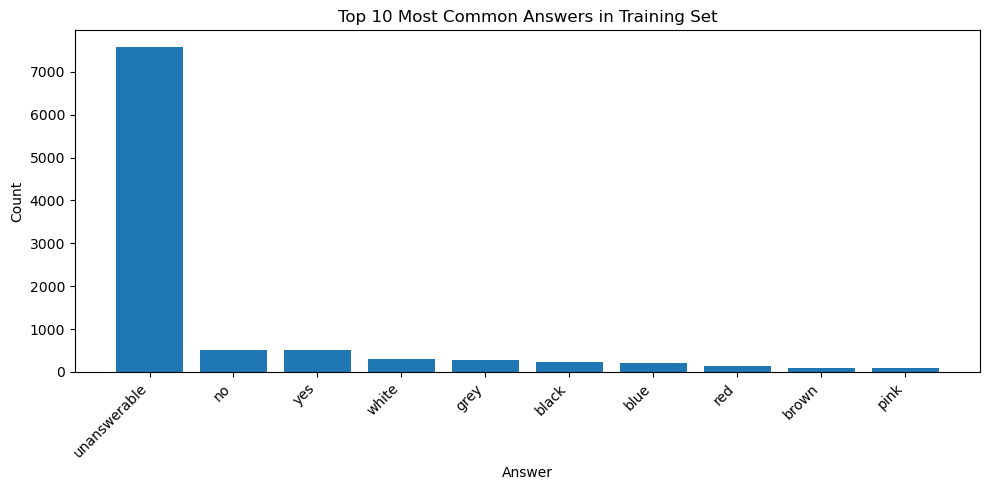

In [37]:
top_n = 10
top_answers = answer_counts.most_common(top_n)

labels = [x[0] for x in top_answers]
values = [x[1] for x in top_answers]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Most Common Answers in Training Set")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [38]:
question_lengths = [len(clean_text(item.get("question", "")).split()) for item in train_data]

print("Question length statistics:")
print("Min:", min(question_lengths))
print("Max:", max(question_lengths))
print("Average:", sum(question_lengths) / len(question_lengths))

Question length statistics:
Min: 2
Max: 59
Average: 6.674072991278078


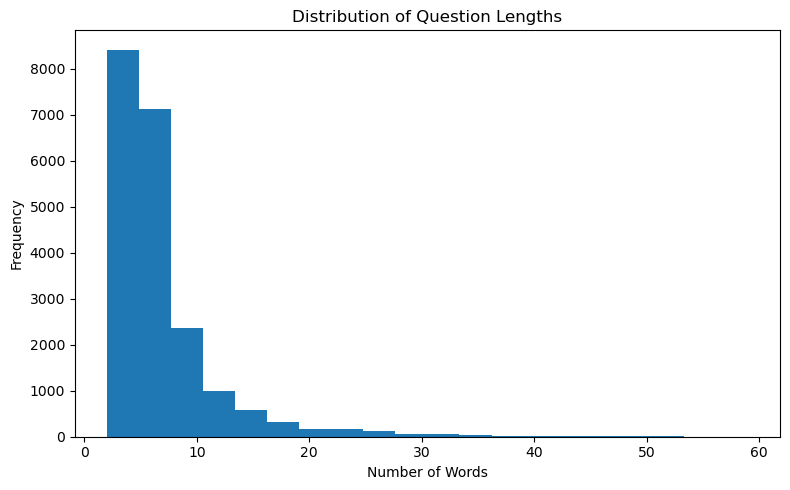

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(question_lengths, bins=20)
plt.title("Distribution of Question Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Image path: /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/raw/vizwiz/train/VizWiz_train_00001702.jpg
Question: What are these?
Final answer: earbuds
Answerable: 1


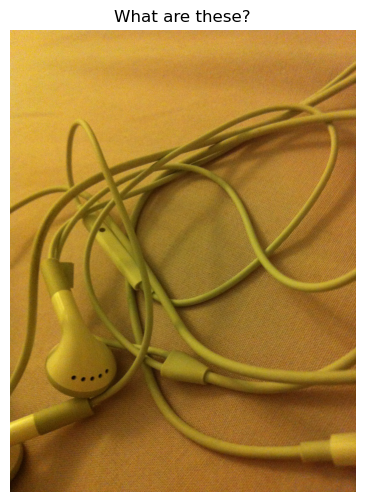

In [40]:
sample_item = random.choice(train_data)

image_name = sample_item.get("image")
image_path = os.path.join(TRAIN_DIR, image_name)

question = sample_item.get("question", "N/A")
final_answer = extract_most_common_answer(sample_item.get("answers", []))
answerable = sample_item.get("answerable", "N/A")

print("Image path:", image_path)
print("Question:", question)
print("Final answer:", final_answer)
print("Answerable:", answerable)

img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(question)
plt.show()


Sample 1
Image: VizWiz_train_00011512.jpg
Question: What is this?
Final answer: unanswerable
Answerable: 1


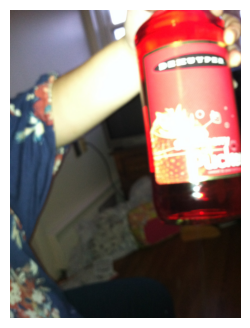


Sample 2
Image: VizWiz_train_00003293.jpg
Question: What type of spice is this?
Final answer: sea salt
Answerable: 1


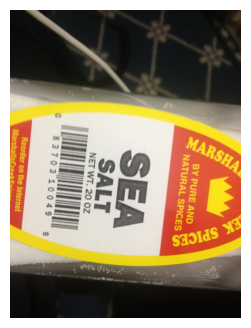


Sample 3
Image: VizWiz_train_00014822.jpg
Question: Fist, thank you.
Final answer: unanswerable
Answerable: 0


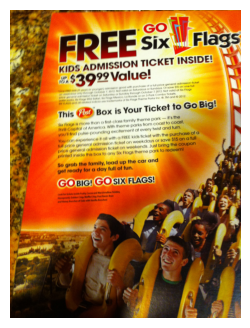

In [41]:
num_samples = 3
random_samples = random.sample(train_data, num_samples)

for idx, item in enumerate(random_samples, 1):
    image_name = item.get("image")
    image_path = os.path.join(TRAIN_DIR, image_name)
    question = item.get("question", "N/A")
    final_answer = extract_most_common_answer(item.get("answers", []))
    answerable = item.get("answerable", "N/A")

    print(f"\nSample {idx}")
    print("Image:", image_name)
    print("Question:", question)
    print("Final answer:", final_answer)
    print("Answerable:", answerable)

    img = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [42]:
rows = []

for item in train_data[:20]:
    rows.append({
        "image": item.get("image"),
        "question": clean_text(item.get("question", "")),
        "final_answer": extract_most_common_answer(item.get("answers", [])),
        "answerable": item.get("answerable", None)
    })

df_preview = pd.DataFrame(rows)
df_preview.head(10)

,image,question,final_answer,answerable
0,VizWiz_train_00000000.jpg,what's the name of this product?,basil leaves,1
1,VizWiz_train_00000001.jpg,can you tell me what is in this can please?,coca cola,1
2,VizWiz_train_00000002.jpg,is this enchilada sauce or is this tomatoes? t...,tomatoes,1
3,VizWiz_train_00000003.jpg,what is the captcha on this screenshot?,t36m,1
4,VizWiz_train_00000004.jpg,what is this item?,solar garden light,1
5,VizWiz_train_00000005.jpg,what's this?,shoes,1
6,VizWiz_train_00000006.jpg,what is in this bottle?,mouthwash,1
7,VizWiz_train_00000007.jpg,this item.,monitor cleaning kit,1
8,VizWiz_train_00000008.jpg,what color do these look?,orange,1
9,VizWiz_train_00000009.jpg,surface look clean? thank you.,yes,1


In [43]:
if "answer_type" in train_data[0]:
    answer_type_counts = Counter(item.get("answer_type", "unknown") for item in train_data)
    print("Answer type distribution:")
    print(answer_type_counts)
else:
    print("No 'answer_type' field found.")

Answer type distribution:
Counter({'other': 13733, 'unanswerable': 5532, 'yes/no': 957, 'number': 301})


In [44]:
missing_question_count = sum(1 for item in train_data if not clean_text(item.get("question", "")))
missing_answers_count = sum(1 for item in train_data if not item.get("answers", []))
missing_image_count = sum(1 for item in train_data if not item.get("image"))

print("Missing/empty question count:", missing_question_count)
print("Missing/empty answers count:", missing_answers_count)
print("Missing image count:", missing_image_count)

Missing/empty question count: 0
Missing/empty answers count: 0
Missing image count: 0


## Initial Observations

- The VizWiz VQA dataset was loaded successfully from the local project directory.
- The dataset contains image filenames, questions, answer lists, and answerability information.
- The answer space is large and diverse, which means answer vocabulary filtering will be important for baseline model training.
- Some examples are likely unanswerable or visually difficult, which supports the motivation for building a trustworthy confidence-aware VQA system.

## Next Step

The next step is to build `scripts/prepare_data.py` to:
1. clean question text,
2. select one final answer per sample,
3. build a top-K answer vocabulary,
4. generate smaller processed train and validation CSV files for initial experiments.